This notebook will walk you through how to gather Capacity Factor data (CF) for solar and wind generation in a zone of interest!

I will be walking through the example of the Midcontinent Independent System Operator (MISO) region between 2020 and 2024, but will point out where you should make your changes to adapt this to your region and time range of interest

Step 0:
Download the following required libraries

In [ ]:
pip install atlite rasterio geopandas cartopy matplotlib numpy xarray

Step 1:
Import the weather data for your rough area of intrest (a big square that we will later cut out to our actual area of interest)

Modify the following lines to your projects intrests:

for year in [2020, 2021, 2022, 2023, 2024]: (change to the years that intrest you)

x=slice(-105, -82), (Change to the Latitude and Longitude points of the top left corner)
y=slice(28, 50), (Change to the Latitude and Longitude points of the bottem right corner)

These are heavy files, and this could take hours to download (about 10 mins per file), so consider letting this run overnight.

In [ ]:
import atlite

for year in [2020, 2021, 2022, 2023, 2024]:
    for month in range(1,13):
        month_str = f"{month:02d}"
        import calendar
        last_day = calendar.monthrange(year, month)[1]
        
        path = f"weather-data-{year}-{month_str}.nc"
        
        cutout = atlite.Cutout(
            path=path,
            module="era5",
            x=slice(-105, -82),
            y=slice(28, 50),
            time=slice(f"{year}-{month_str}-01", f"{year}-{month_str}-{last_day}"),
        )
        cutout.prepare(features=["wind", "influx", "height", "temperature"])
        print(f"Done: {year}-{month_str}")

In [ ]:
import atlite
import logging
logging.basicConfig(level=logging.INFO)

for year in [2022, 2023, 2024]:
    path = f"miso-{year}.nc"
    cutout = atlite.Cutout(
        path=path,
        module="era5",
        x=slice(-105, -82),
        y=slice(28, 50),
        time=slice(f"{year}-01-01", f"{year}-12-31"),
    )
    cutout.prepare(
        features=["wind", "influx", "height", "temperature"],
        monthly_requests=True,      # breaks the year into monthly CDS requests
        concurrent_requests=True,   # posts all 12 months at once instead of sequentially
    )
    print(f"Done: {year}")

Step 2: Merge all the individual weather files into one time series large file

This step will skip any file that is empty in the event it downloaded wrong. It will point out which files it skipped. I highly recommend going back and redownloading that skipped file

In [ ]:
import xarray as xr
import os

data_dir = "Insert the Path you want to save the weather data file to"
#Example: data_dir = "/Users/mshaaban/miso_folder"


datasets = []
for year in [2020, 2021, 2022, 2023, 2024]: # Change the years as needed
    for month in range(1, 13):
        path = os.path.join(data_dir, f"weather-data-{year}-{month:02d}.nc")
        if os.path.exists(path):
            datasets.append(xr.open_dataset(path))
        else:
            print(f"Skipping missing file: {path}")

combined = xr.concat(datasets, dim="time")
print(combined)

Then, once it is all combined, save the file to your device
The last portion of the path in the first line can be named whatever you desire,
It is called combined_weather_data for now

In [ ]:
combined.to_netcdf("Insert the Path you want to save the combined weather data file to/combined_weather_data.nc")
print("Saved.")

Lastly is to reload the combined file so that the 'cutout' variable points to the new temporal file

In [ ]:
import atlite

combined_path = "Insert the path to your combined_weather_data.nc file here"
# Example: "/Users/mshaaban/miso_folder/combined_weather_data.nc"

cutout = atlite.Cutout(path=combined_path)
print(cutout)
print(f"Time range: {cutout.coords['time'].values[0]} to {cutout.coords['time'].values[-1]}")
print(f"Spatial extent: x={cutout.x.values[[0,-1]]}, y={cutout.y.values[[0,-1]]}")

Step 3: Load in the shape file for your region, ideally a .geojson file

Cordinate Referance System (CRS) is an important value for atlite for area calculations. Using the right CRS for your area matters alot. Here are some CRS EPSGs for key areas:

Contiguous US: 5070
Europe: 3035
Australia: 3577
Middle East & Asia: 32638
Africa: 203033
North America (in full): 102008

EPSG:5070
(224, 6)


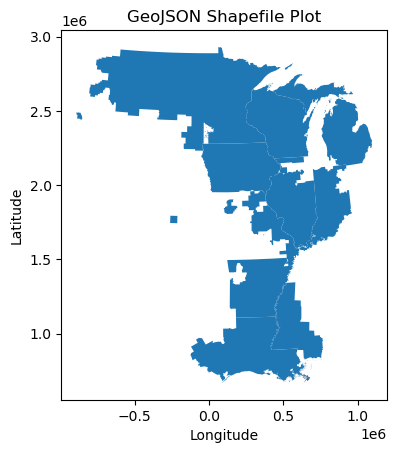

In [16]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt

# These next few lines are to get the shapefile data from 
# the arcgis website and save it as a geojson file. 
# You can skip this step if you already have a geojson file for your respective region.
#Example: https://services1.arcgis.com/0MSEUqKaxRlEPj5P/arcgis/rest/services/MISO_Boundary/FeatureServer/0/query?where=1%3D1&outFields=*&outSR=4326&f=geojson"
website= 'https://services3.arcgis.com/fwwoCWVtaahwlvxO/arcgis/rest/services/MISO_Market/FeatureServer/' 
url = website + "/41/query?where=1%3D1&outFields=*&outSR=4326&f=geojson"
r = requests.get(url)
with open("/Users/mshaaban/notebook_steps_to_get_weather_within_MISO/miso_zone_test.geojson", "wb") as f:
    f.write(r.content)
# Here is an example of the path to save the geojson file: 
# "/Users/mshaaban/miso_folder/miso_boundary.geojson"
# The last part of the path (miso_boundary.geojson) is the name of the geojson file. 
# You can change it as needed (ie, call your geojson file whatever you desire).

miso = gpd.read_file("/Users/mshaaban/notebook_steps_to_get_weather_within_MISO/miso_zone_test.geojson") 
miso = miso.to_crs("5070") 

print(miso.crs)
print(miso.shape)
miso.plot()
plt.title("GeoJSON Shapefile Plot")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


EPSG:5070
(1, 7)


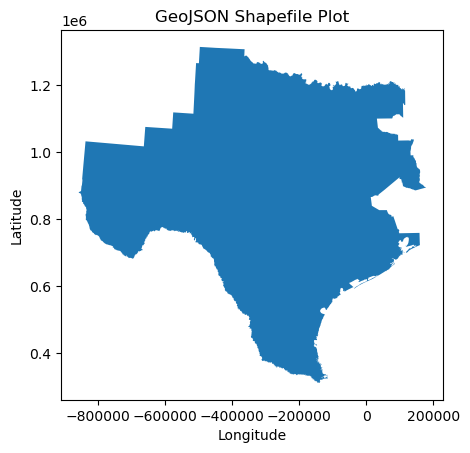

In [ ]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt

# These next few lines are to get the shapefile data from 
# the arcgis website and save it as a geojson file. 
# You can skip this step if you already have a geojson file for your respective region.
#Example: https://services1.arcgis.com/0MSEUqKaxRlEPj5P/arcgis/rest/services/MISO_Boundary/FeatureServer/0/query?where=1%3D1&outFields=*&outSR=4326&f=geojson"
website = "Enter the URL to the arcgis website here" 
url = website + "/0/query?where=1%3D1&outFields=*&outSR=4326&f=geojson"
r = requests.get(url)
with open("Enter the path to save the geojson file here", "wb") as f:
    f.write(r.content)
# Here is an example of the path to save the geojson file: 
# "/Users/mshaaban/miso_folder/miso_boundary.geojson"
# The last part of the path (miso_boundary.geojson) is the name of the geojson file. 
# You can change it as needed (ie, call your geojson file whatever you desire).

miso = gpd.read_file("Insert the path to your geojson file here") 
miso = miso.to_crs("ENTER YOUR DESIRED CRS HERE") 

print(miso.crs)
print(miso.shape)
miso.plot()
plt.title("GeoJSON Shapefile Plot")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


Step 4: Build an availability matrix.

We assume that all land is usable, but it is possable to exclude certain regions within this step (ie, think of cities or nature preservations)

In [ ]:
import geopandas as gpd
import atlite
from atlite.gis import ExclusionContainer

miso = gpd.read_file("Insert the path to your geojson file here")
miso = miso.to_crs("Insert the CRS you want to use here").geometry

excluder = ExclusionContainer(crs="Insert the CRS you want to use here", res=1000) # "res=1000" means 1km resolution, you can change it as needed

A = cutout.availabilitymatrix(miso, excluder)
print(A)

Step 5: Build capacity matrix:

We use power capacity per land area density value of 2 for both onshore wind turbines and fixed tilt solar. If you wish to model a different Capacity density, you can change the '2' at the end on the last two lines of code.

In [ ]:
import xarray as xr

area = cutout.grid.set_index(["y", "x"]).to_crs("Insert CRS here").area / 1e6  # km²
area = xr.DataArray(area, dims=("spatial",))

capacity_matrix_wind  = A.stack(spatial=["y", "x"]) * area * 2   # MW/km²
capacity_matrix_solar = A.stack(spatial=["y", "x"]) * area * 2  # MW/km²

Step 6: Calculate the CF

In [ ]:
# Wind
wind_cf = cutout.wind(
    matrix=capacity_matrix_wind,
    turbine="Vestas_V90_3MW",
    index=miso.index,
    per_unit=True
)
print("Wind done")

# Solar
solar_cf = cutout.pv(
    panel="CSi",
    orientation={"slope": 30.0, "azimuth": 180.0},
    matrix=capacity_matrix_solar,
    index=miso.index,
    tracking=None,+
    per_unit=True
)
print("Solar done")

Step 7: Save the calculated CF to a file on your computer

Once again, change the path to your desired file path and name

In [ ]:
wind_cf.to_netcdf("Enter the Path you want to save the wind capacity factor file to")
#Example: wind_cf.to_netcdf("/Users/mshaaban/miso_folder/miso_wind_cf_2020_2024.nc")
solar_cf.to_netcdf("Enter the Path you want to save the solar capacity factor file to")
#Example: solar_cf.to_netcdf("/Users/mshaaban/miso_folder/miso_solar_cf_2020_2024.nc")
print("Saved.")

The code below converts .nc files to .csv files which makes it easier to inspect the data you have

In [6]:
import xarray as xr
import pandas as pd
data = xr.open_dataset('/Users/mshaaban/notebook_steps_to_get_weather_within_MISO/miso-2022.nc')

df = data.to_dataframe().reset_index()
#df.columns = ['time', 'Spatial', 'capacity_factor']  # Rename columns as needed

df.to_csv("/Users/mshaaban/notebook_steps_to_get_weather_within_MISO/miso-2022.csv", index=False)
#Example: df.to_csv("/Users/mshaaban/miso_folder/miso_solar_cf_2020_2024.csv", index=False)
print("Saved to CSV.")

Saved to CSV.


In [5]:
import xarray as xr
import pandas as pd

ds = xr.open_dataset('/Users/mshaaban/notebook_steps_to_get_weather_within_MISO/miso-2022.nc')
print(ds.data_vars)  # see what variables are in there

Data variables:
    wnd100m               (time, y, x) float32 290MB ...
    wnd_azimuth           (time, y, x) float32 290MB ...
    roughness             (time, y, x) float32 290MB ...
    influx_toa            (time, y, x) float32 290MB ...
    influx_direct         (time, y, x) float32 290MB ...
    influx_diffuse        (time, y, x) float32 290MB ...
    albedo                (time, y, x) float32 290MB ...
    solar_altitude        (time, y, x) float64 580MB ...
    solar_azimuth         (time, y, x) float64 580MB ...
    height                (y, x) float32 33kB ...
    temperature           (time, y, x) float32 290MB ...
    soil temperature      (time, y, x) float32 290MB ...
    dewpoint temperature  (time, y, x) float32 290MB ...
